## Task: Predict Food Delivery Time

You are provided with a food delivery dataset that includes features such as delivery distance, restaurant preparation time, traffic conditions, and order details. Your objective is to develop a regression model that accurately predicts the delivery time in minutes.

Your target is the column: "delivery_time".

You are provided with the code to download and load the csv file.

Your work will be evaluated based on the completion of the following tasks:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Part 1: Read Data

**Tasks:**

1. Read the dataset `Q1_data.csv` using `read_csv()`
2. Inspect the first few rows using `head()`
3. Display dataset information using `info()`
4. Show statistical description using `describe()`
5. Plot the target distribution (delivery_time)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q1-ka-ai-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'q1-ka-ai-2026' dataset.
Path to dataset files: /kaggle/input/q1-ka-ai-2026


In [3]:
# Task 1: Write your code here:
data_path = os.path.join(path,'Q1_data.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (1663, 9)


In [ ]:
# Task 2: Write your code here:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [ ]:
# Task 3: Write your code here:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1663 non-null   int64  
 1   Distance_km             1663 non-null   float64
 2   Weather                 1608 non-null   object 
 3   Traffic_Level           1612 non-null   object 
 4   Time_of_Day             1613 non-null   object 
 5   Vehicle_Type            1663 non-null   object 
 6   Preparation_Time_min    1663 non-null   int64  
 7   Courier_Experience_yrs  1614 non-null   float64
 8   Delivery_Time           1557 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 117.1+ KB


In [ ]:
# Task 4: Write your code here:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
count,1663.000000,1663.000000,1663.000000,1614.000000,1557.000000
mean,495.866506,10.049910,17.038485,4.586741,56.640976
std,289.514088,5.684406,7.230498,2.916843,22.135919
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,246.500000,5.130000,11.000000,2.000000,41.000000
50%,490.000000,10.160000,17.000000,5.000000,55.000000
75%,745.500000,14.980000,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


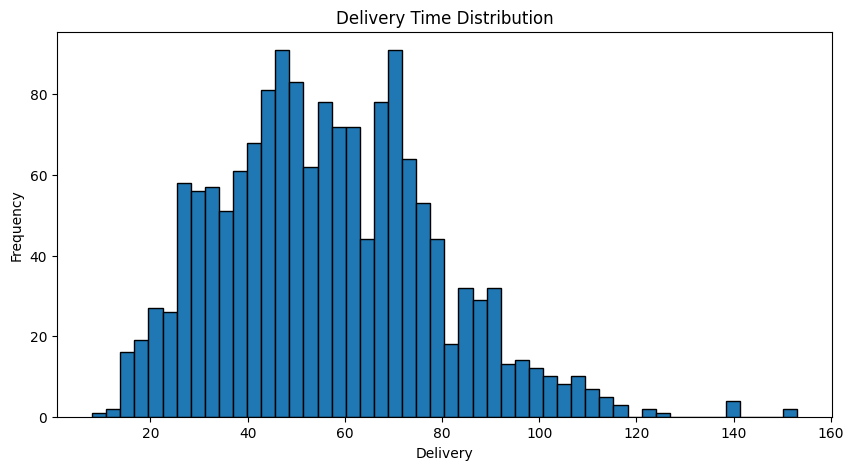

In [ ]:
# Task 5: Write your code here:

plt.figure(figsize=(10, 5))
plt.hist(df['Delivery_Time'].dropna(), bins=50, edgecolor='black')
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery')
plt.ylabel('Frequency')
plt.show()

# Part 2: Data Cleaning

**Tasks:**

Inspect and fix the following when needed:

1. **Drop the 'Order_ID' column from the data**
2. **Handle missing values appropriately** (Hint: I guess you want to have a closer look at the columns with missing values :) )
3. **Check and remove duplicates** if any exist
4. **Encode categorical variables** if needed
5. **Apply feature scaling for all features** (Use StandardScaler)
6. **Check for target imbalance and state if it is imbalanced or not** (keep this cell empty if not needed)

In [ ]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time'],
      dtype='object')

In [ ]:
# Task 1: Write your code here:
df.drop(columns = 'Order_ID',inplace=True)

In [ ]:
# Task 2: Write your code here:
df.isnull().sum()

,0
Distance_km,0
Weather,55
Traffic_Level,51
Time_of_Day,50
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,49
Delivery_Time,106


In [13]:
# dropping missing target labels
df.dropna(subset="Delivery_Time",inplace=True)

In [ ]:
df.isnull().sum()

,0
Distance_km,0
Weather,50
Traffic_Level,48
Time_of_Day,47
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,45
Delivery_Time,0


In [4]:
cols = ['Weather','Traffic_Level','Time_of_Day']
for c in cols:
  df[c]= df[c].fillna(df[c].mode()[0])

In [5]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [6]:
# Task 3: Write your code here:
def check_duplicates(df):
  duplicates = df.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df)

Number of Duplicate Samples: 557
Dropping Duplicates...
Duplicates Dropped.


In [7]:
# Task 4: Write your code here:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object')

In [8]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [9]:
# Task 5: Write your code here:
from sklearn.preprocessing import StandardScaler #import StandardScaler
numerical_cols = df.select_dtypes(include=['number']).columns.drop('Delivery_Time')
print('data before scaling:\n', numerical_cols) #show before scaling
standard_scaler = StandardScaler() # Instantiate StandardScaler
df[numerical_cols] = standard_scaler.fit_transform(df[numerical_cols]) # Apply fit_transform

data before scaling:
 Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs'],
      dtype='object')


In [10]:
# Task 6: Write your code here:
df['Delivery_Time'].head()

,Delivery_Time
0,43.0
1,84.0
2,59.0
3,37.0
4,68.0


Contniuous values dont have imbalance in target.

# Part 3: Modeling

**Tasks:**

1. Split the dataset into features (X) and target (y)
2. Use the correct split: **KFold** OR **StratifiedKFold**
3. Train a **RandomForest** model
4. Evaluate using **MAE (Mean Absolute Error) ONLY**
5. Print the averaged score across all folds

In [15]:
# Task 1: Write your code here:
X = df.drop('Delivery_Time', axis=1)
y = df['Delivery_Time']

In [16]:
# Task 2,3,4,5: Write your code here:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
# Define K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(class_weight='balanced')
mae_scores = []

# Iterate through folds
for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    # indexing for each fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # print shapes
    print(f"Fold {fold}")
    print("  X_train shape:", X_train.shape)
    print("  X_test shape :", X_test.shape)
    print("  y_train shape:", y_train.shape)
    print("  y_test shape :", y_test.shape)
    print("-" * 30)

    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Calculate metrics
    mae_scores.append(mean_absolute_error(y_test, y_pred))

mae_scores = np.array(mae_scores)

print(f"5-Fold CV Results:")
print(f"MAE:  ${mae_scores.mean():,.2f}")


Fold 1
  X_train shape: (800, 8)
  X_test shape : (200, 8)
  y_train shape: (800,)
  y_test shape : (200,)
------------------------------
Fold 2
  X_train shape: (800, 8)
  X_test shape : (200, 8)
  y_train shape: (800,)
  y_test shape : (200,)
------------------------------
Fold 3
  X_train shape: (800, 8)
  X_test shape : (200, 8)
  y_train shape: (800,)
  y_test shape : (200,)
------------------------------
Fold 4
  X_train shape: (800, 8)
  X_test shape : (200, 8)
  y_train shape: (800,)
  y_test shape : (200,)
------------------------------
Fold 5
  X_train shape: (800, 8)
  X_test shape : (200, 8)
  y_train shape: (800,)
  y_test shape : (200,)
------------------------------
5-Fold CV Results:
MAE:  $12.92


# Part 4: Plots

**Tasks:**

1. Plot feature importance from your trained model
2. Plot predicted delivery time histogram

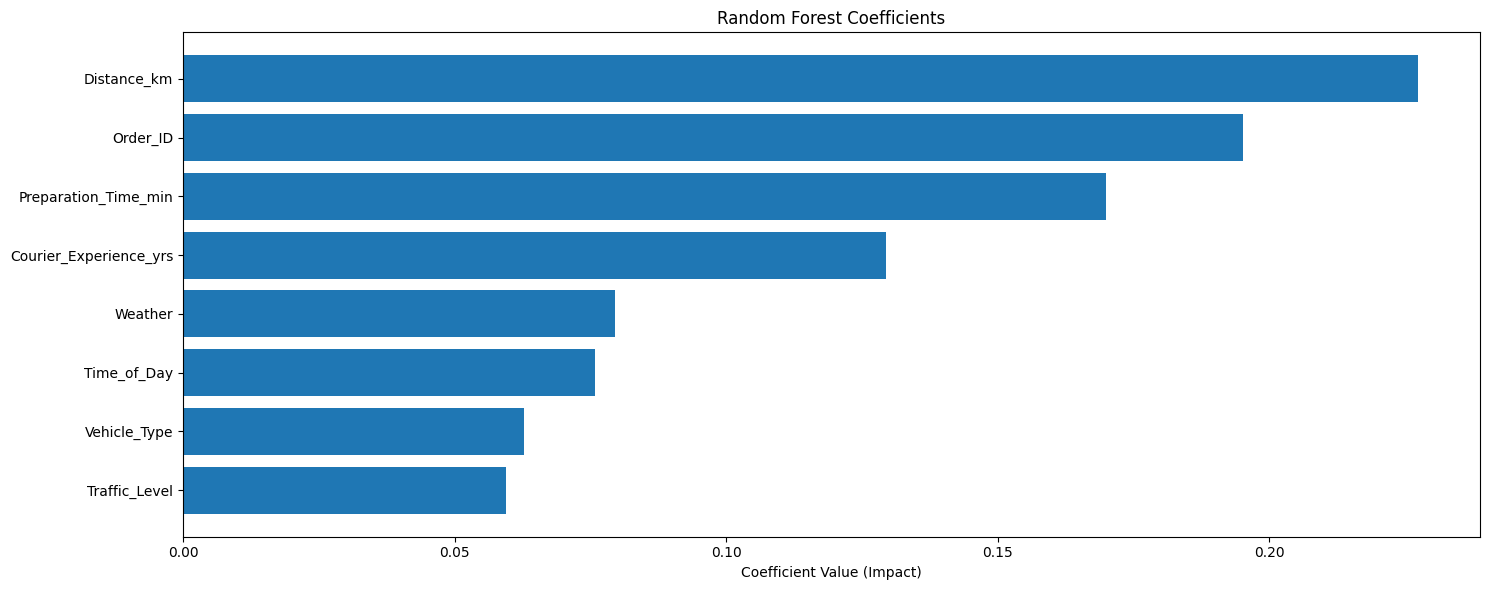

In [20]:
# Task 1: Write your code here:
coeffs = {}

coeffs['RandomForest'] = model.feature_importances_

fig, axes = plt.subplots(figsize=(15, 6))
features = X.columns
coef = model.feature_importances_
absolute_coef = np.abs(coef)
sorted_idx = np.argsort(absolute_coef)

axes.barh(features[sorted_idx], coef[sorted_idx])
axes.set_title(f"Random Forest Coefficients")
axes.set_xlabel("Coefficient Value (Impact)")

plt.tight_layout()
plt.show()

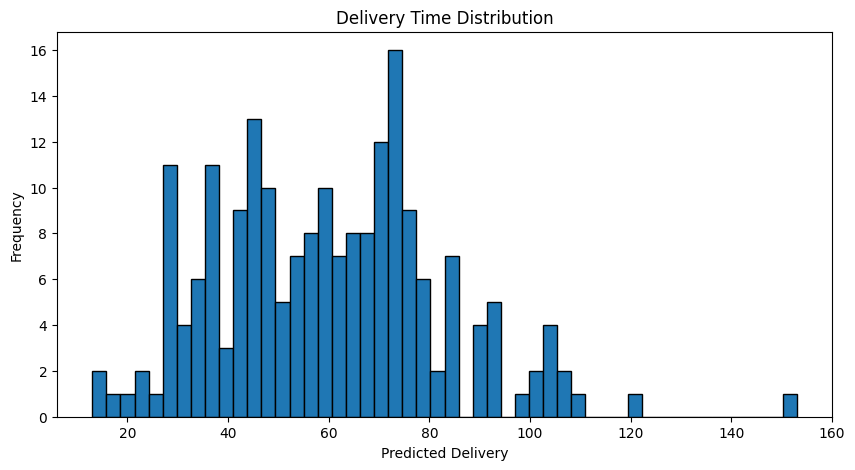

In [21]:
# Task 2: Write your code here:
plt.figure(figsize=(10, 5))
plt.hist(y_test, bins=50, edgecolor='black')
plt.title('Delivery Time Distribution')
plt.xlabel('Predicted Delivery')
plt.ylabel('Frequency')
plt.show()

# Part 5: Bonus - Ensemble

**Task:**

Why use one model? Let's use 2 then merge!

Rewrite the KFold loop such that you:
1. Train **2 different models** inside the loop at the same time in each iteration
2. Average their predictions
3. Calculate the MAE metric on the averaged predictions

Use RandomForestRegressor and CatBoostRegressor.

In [ ]:
# Task Bonus: Write your code here:

In [22]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [23]:
from catboost import CatBoostRegressor

In [24]:
models = {
  "Random Forest Regressor": RandomForestRegressor(n_estimators=200),
  "CatBoost": CatBoostRegressor(verbose=0)
}

In [25]:
all_results = {}

for name in models:
  all_results[name] = {'mae': []}

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/5")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    all_results[model_name]["mae"].append(mae)


Fold 1/5
Training Random Forest Regressor...
Training CatBoost...

Fold 2/5
Training Random Forest Regressor...
Training CatBoost...

Fold 3/5
Training Random Forest Regressor...
Training CatBoost...

Fold 4/5
Training Random Forest Regressor...
Training CatBoost...

Fold 5/5
Training Random Forest Regressor...
Training CatBoost...


In [27]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  MAE:  {np.mean(all_results[model_name]['mae']):.4f}")


Random Forest Regressor:
  MAE:  8.0128

CatBoost:
  MAE:  7.3744
